# TFT Forecaster — Daily Store Revenue (2015-10-01 → 2015-12-31)

A Temporal Fusion Transformer trained on per-store daily revenue with calendar
events as **known-future covariates**. Outputs a 92-day forecast per store and
writes a Kaggle-style submission CSV under `Results/`.

**Order**: imports → data prep → dataset → train → predict → submission → plot → export.  
Run cells top-to-bottom. Verify GPU is detected in the imports cell.

In [3]:
# Imports & GPU check
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42, workers=True)

print(f"PyTorch: {torch.__version__}")
print(f"Lightning: {pl.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device : {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
    # Use Tensor Cores when present (RTX 20xx+ / A100 / etc.)
    torch.set_float32_matmul_precision("medium")
else:
    print("No GPU detected — training will run on CPU (slow). See README at bottom.")

Seed set to 42


PyTorch: 2.9.1+cu130
Lightning: 2.6.5
CUDA available: True
CUDA device : NVIDIA GeForce RTX 5080
CUDA version: 13.0


## 1. Data preparation

Build a continuous (store, date) grid covering history + the 92-day forecast horizon, merge revenue and calendar events, and engineer time features.

In [4]:
# Paths are relative to this notebook's working directory (DeepLearning/).
TRAIN_PATH = "train.csv"
EVENTS_PATH = "calendar_events.csv"

train = pd.read_csv(TRAIN_PATH, parse_dates=["date"])
events = pd.read_csv(EVENTS_PATH, parse_dates=["date"])

print(f"train: {train.shape}, dates {train['date'].min().date()} → {train['date'].max().date()}")
print(f"events: {events.shape}, distinct events (raw): {events['event'].nunique()}")
print(f"stores: {sorted(train['store_id'].unique())}")

FORECAST_START = pd.Timestamp("2015-10-01")
FORECAST_END   = pd.Timestamp("2015-12-31")
HORIZON = (FORECAST_END - FORECAST_START).days + 1
print(f"Forecast: {HORIZON} days  ({FORECAST_START.date()} → {FORECAST_END.date()})")

# When multiple events share a date (e.g. "OrthodoxEaster, Easter"), keep the first.
events["event"] = events["event"].str.split(",").str[0].str.strip()
events_map = dict(zip(events["date"], events["event"]))

# Full (store, date) grid covering history + the forecast window.
date_min = train["date"].min()
all_dates = pd.date_range(date_min, FORECAST_END, freq="D")
all_stores = sorted(train["store_id"].unique())

grid = pd.MultiIndex.from_product(
    [all_stores, all_dates], names=["store_id", "date"]
).to_frame(index=False)

df = grid.merge(train[["store_id", "date", "revenue"]], on=["store_id", "date"], how="left")

# Time / calendar features (all become known-future covariates)
df["dow"]      = df["date"].dt.dayofweek.astype(str)
df["month"]    = df["date"].dt.month.astype(str)
df["day"]      = df["date"].dt.day.astype(np.float32)
df["week"]     = df["date"].dt.isocalendar().week.astype(np.float32)
df["event"]    = df["date"].map(events_map).fillna("none").astype(str)
df["is_event"] = (df["event"] != "none").astype(np.float32)

# Integer time index (days since dataset start)
df["time_idx"] = (df["date"] - date_min).dt.days.astype(np.int64)

# Repair any historical gaps (forward-fill within each store); future stays NaN -> 0
mask_past = df["date"] < FORECAST_START
df.loc[mask_past, "revenue"] = (
    df.loc[mask_past].groupby("store_id")["revenue"].transform(lambda s: s.ffill().bfill())
)
df["revenue"] = df["revenue"].fillna(0.0).astype(np.float32)

df["store_id"] = df["store_id"].astype(str)

print("\nHead:")
print(df.head())
print(f"\nTotal rows: {len(df):,} | stores: {df['store_id'].nunique()} | "
      f"date range: {df['date'].min().date()} → {df['date'].max().date()}")

train: (18766, 4), dates 2011-01-29 → 2015-09-30
events: (162, 2), distinct events (raw): 34
stores: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Forecast: 92 days  (2015-10-01 → 2015-12-31)

Head:
  store_id       date        revenue dow month   day  week event  is_event  \
0        0 2011-01-29  204126.515625   5     1  29.0   4.0  none       0.0   
1        0 2011-01-30  197426.421875   6     1  30.0   4.0  none       0.0   
2        0 2011-01-31  144267.265625   0     1  31.0   5.0  none       0.0   
3        0 2011-02-01  151903.000000   1     2   1.0   5.0  none       0.0   
4        0 2011-02-02  117399.882812   2     2   2.0   5.0  none       0.0   

   time_idx  
0         0  
1         1  
2         2  
3         3  
4         4  

Total rows: 19,778 | stores: 11 | date range: 2011-01-29 → 2015-12-31


## 2. Build TimeSeriesDataSet

* **Encoder = 180 days** of recent history per training sample.
* **Decoder = 92 days** matching the forecast horizon.
* `event`, `dow`, `month` are *known-future* categoricals (we know the holiday calendar in advance).
* Validation is constructed via `predict=True` so it yields exactly **one sample per store**, with the decoder pinned to 2015-10-01 → 2015-12-31.

In [5]:
MAX_ENCODER_LENGTH    = 180     # ~6 months of history per sample
MAX_PREDICTION_LENGTH = HORIZON  # 92

training_cutoff = int(
    df.loc[df["date"] == FORECAST_START - pd.Timedelta(days=1), "time_idx"].iloc[0]
)
print(f"training_cutoff (last train time_idx): {training_cutoff} "
      f"-> {df.loc[df['time_idx']==training_cutoff,'date'].iloc[0].date()}")

training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="revenue",
    group_ids=["store_id"],
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
    static_categoricals=["store_id"],
    time_varying_known_categoricals=["event", "dow", "month"],
    time_varying_known_reals=["time_idx", "is_event", "day", "week"],
    time_varying_unknown_reals=["revenue"],
    target_normalizer=GroupNormalizer(groups=["store_id"], transformation="softplus"),
    categorical_encoders={
        "event": NaNLabelEncoder(add_nan=True),
        "dow":   NaNLabelEncoder(add_nan=True),
        "month": NaNLabelEncoder(add_nan=True),
    },
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=False,
)

validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

BATCH_SIZE = 64
# num_workers=0 on Windows: avoids notebook multiprocessing pitfalls.
train_dataloader = training.to_dataloader(train=True,  batch_size=BATCH_SIZE, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print(f"Training samples: {len(training):,}")
print(f"Validation samples: {len(validation):,}")

training_cutoff (last train time_idx): 1705 -> 2015-09-30
Training samples: 15,785
Validation samples: 11


## 3. Configure & train the TFT

In [6]:
early_stop = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=8, mode="min")
lr_monitor = LearningRateMonitor(logging_interval="epoch")

trainer = pl.Trainer(
    max_epochs=30,
    accelerator="auto",   # picks GPU when available
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor],
    enable_progress_bar=True,
    log_every_n_steps=20,
)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=3e-3,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    output_size=7,            # 7 quantiles (default of QuantileLoss)
    loss=QuantileLoss(),
    log_interval=20,
    reduce_on_plateau_patience=3,
)

print(f"TFT parameters: {sum(p.numel() for p in tft.parameters()):,}")

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT parameters: 308,667


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    549 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    576 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 43.7 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 36.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 308 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 308 K                                                                                                
Total estimated model params size (MB): 1.235                                                                      
Modules in train mode: 398                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 4. Generate predictions for 2015-10-01 → 2015-12-31

In [7]:
# Reload best checkpoint (lower val_loss) when one was saved
best_ckpt = trainer.checkpoint_callback.best_model_path if trainer.checkpoint_callback else ""
if best_ckpt:
    print(f"Loading best checkpoint: {best_ckpt}")
    best_tft = TemporalFusionTransformer.load_from_checkpoint(best_ckpt)
else:
    print("No checkpoint saved — using final model state.")
    best_tft = tft

# `mode="prediction"` returns the median quantile (point forecast).
out = best_tft.predict(
    val_dataloader,
    mode="prediction",
    return_x=True,
    return_index=True,
)
preds = out.output.cpu().numpy()       # (n_stores, 92)
index = out.index.reset_index(drop=True)  # store_id, time_idx (decoder start)

print(f"Predictions shape: {preds.shape}")
print(index.head())

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Loading best checkpoint: C:\Users\Guy\Documents\M.S. MLDS\Advanced ML\FinalProject\AdvancedML_Project\DeepLearning\lightning_logs\version_0\checkpoints\epoch=8-step=2214.ckpt
Predictions shape: (11, 92)
   time_idx store_id
0      1706        0
1      1706        1
2      1706       10
3      1706        2
4      1706        3


## 5. Build the submission file

In [8]:
records = []
for i, row in index.iterrows():
    store_id = row["store_id"]
    start_idx = int(row["time_idx"])
    for j in range(preds.shape[1]):
        date = date_min + pd.Timedelta(days=start_idx + j)
        records.append({
            "store_id": store_id,
            "date": date,
            "prediction": float(preds[i, j]),
        })

submission_long = pd.DataFrame(records)
submission_long["prediction"] = submission_long["prediction"].clip(lower=0)  # revenue ≥ 0

submission = submission_long.copy()
submission["id"] = (
    submission["store_id"].astype(str) + "_" + submission["date"].dt.strftime("%Y%m%d")
)
submission = submission[["id", "prediction"]]

expected = len(all_stores) * HORIZON
print(f"Submission rows: {len(submission)}  (expected {expected})")
print(submission.head())
print(submission.tail())

Submission rows: 1012  (expected 1012)
           id    prediction
0  0_20151001  266823.40625
1  0_20151002  326215.06250
2  0_20151003  379257.12500
3  0_20151004  391422.18750
4  0_20151005  307262.06250
              id    prediction
1007  9_20151227  22769.892578
1008  9_20151228  20379.380859
1009  9_20151229  21637.939453
1010  9_20151230  21972.609375
1011  9_20151231  22330.876953


## 6. Plot history vs. forecast per store

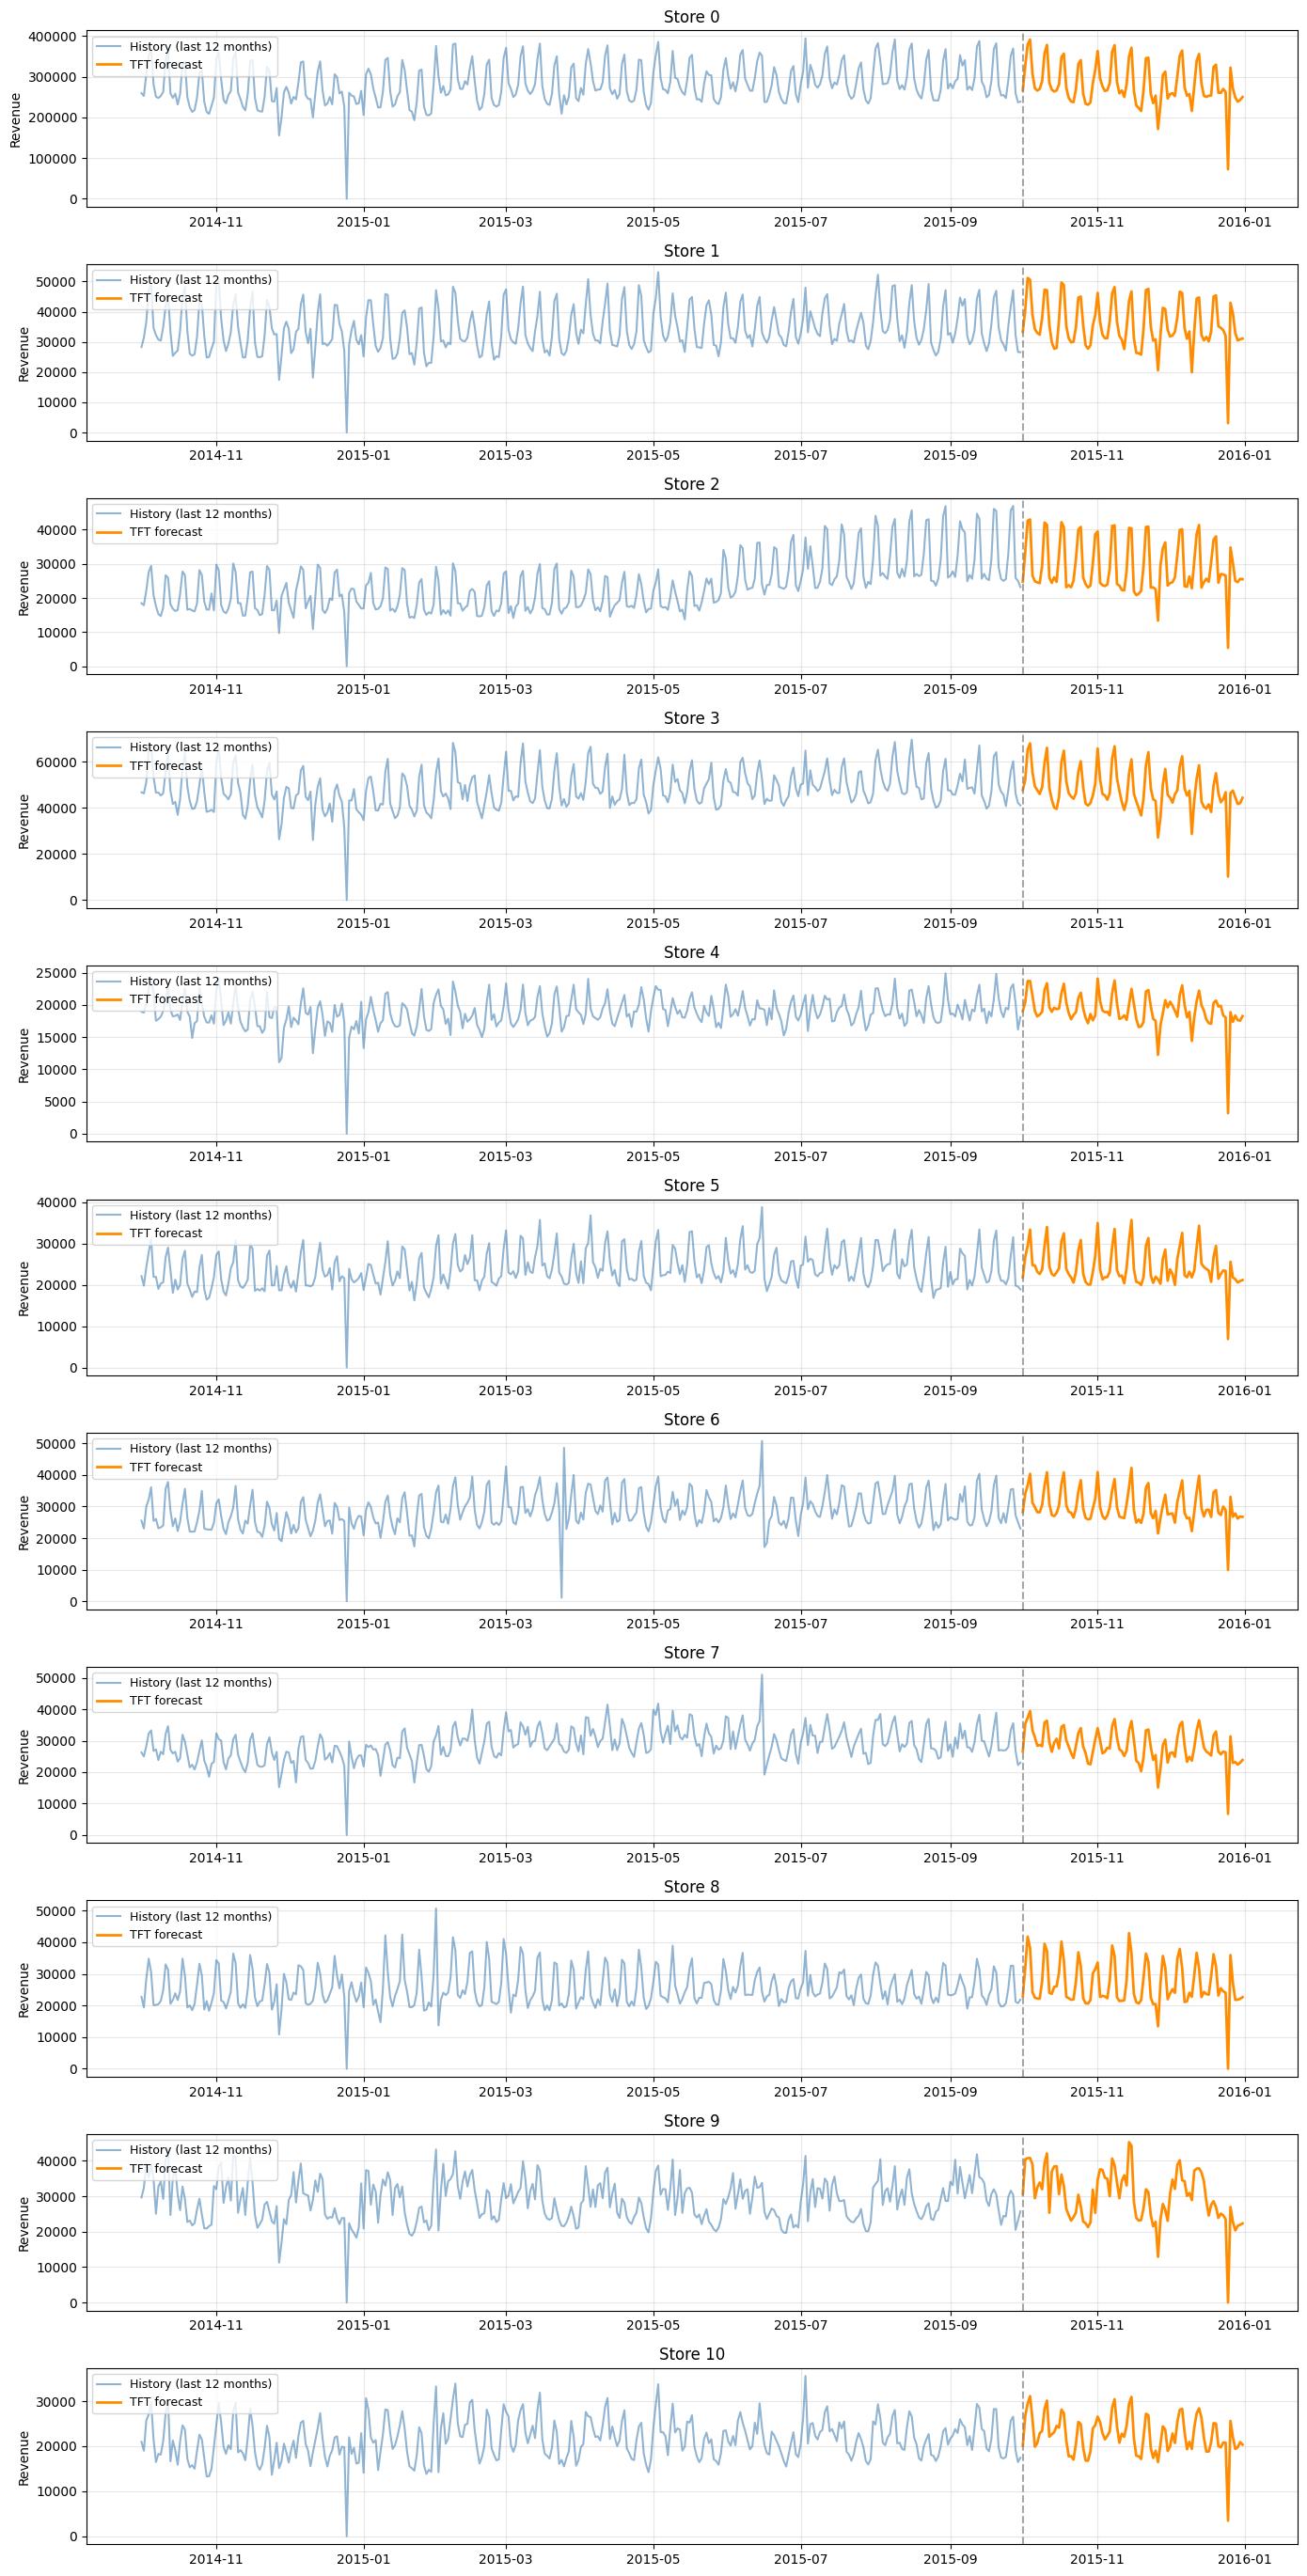

Saved plot: Results\forecast_plots.png


In [9]:
RESULTS_DIR = "Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

n = len(all_stores)
fig, axes = plt.subplots(n, 1, figsize=(14, 2.5 * n), sharex=False)
if n == 1:
    axes = [axes]

history_window = pd.Timedelta(days=365)
for ax, store_id in zip(axes, all_stores):
    store_str = str(store_id)
    hist = df[
        (df["store_id"] == store_str)
        & (df["date"] < FORECAST_START)
        & (df["date"] >= FORECAST_START - history_window)
    ]
    ax.plot(hist["date"], hist["revenue"], color="steelblue", alpha=0.6,
            label="History (last 12 months)")

    pred_rows = submission_long[submission_long["store_id"] == store_str].sort_values("date")
    ax.plot(pred_rows["date"], pred_rows["prediction"], color="darkorange",
            linewidth=2, label="TFT forecast")

    ax.axvline(FORECAST_START, linestyle="--", color="gray", alpha=0.7)
    ax.set_title(f"Store {store_id}")
    ax.set_ylabel("Revenue")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "forecast_plots.png")
plt.savefig(plot_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved plot: {plot_path}")

## 7. Export submission CSV to `Results/`

In [10]:
submission_path = os.path.join(RESULTS_DIR, "forecast_submission.csv")
submission.to_csv(submission_path, index=False)
print(f"Saved submission     : {submission_path}  ({len(submission)} rows)")

long_path = os.path.join(RESULTS_DIR, "forecast_predictions_long.csv")
submission_long.to_csv(long_path, index=False)
print(f"Saved long-form preds: {long_path}")

Saved submission     : Results\forecast_submission.csv  (1012 rows)
Saved long-form preds: Results\forecast_predictions_long.csv
